# Project Title
*Analysis of Rainfall Variability in Bangladesh (1970-2016)*

## Introduction 
*Rainfall is crucial for the economic and agricultural sector of Bangladesh. Data was collected from 1970 to 2016 across 33 weather stations by Bangladesh Meteorological Department and was analyzed using Python. Rainfall pattern showed an increase in the Coefficient of Variation across the study period.*

## Problem Statement

*Across 33 different weather stations in Bangladesh, a 35% increase in rainfall variability was recorded between 1970 and 2016. This change can affect the lives of millions of farmers. Such variability can cause serious disruptions in any type of agricultural task.*


Rainfall variability across Bangladesh's weather stations does not follow one clear trend between 1970 and 2016. While some stations show increased variability, especially in recent years, others have become more stable, creating an uneven pattern that complicates agricultural planning and flood risk management.

## Objectives:
__Questions that will guide the analysis to solve the problem__

- What are the top 3 regions with the highest average rainfall in the period of 1970-2016? :)
- How does the Coefficient of Variation of rainfall in different weather stations in Bangladesh change across decades from 1970 to 2016? :)
- What are the best months regarding the highest average rainfall with the lowest coefficient of variation for planting, from 1970 to 2016?
- Which season recorded the highest number of months exceeding the Standard Deviation-based rainfall threshold between 1970 and 2016?
- What is the correlation between the average rainfall and the Coefficient of Variation across weather stations, from 1970 to 2016?

## Exploratory Data Analysis (EDA):

### Data Info:
__Getting the data and exploring it (includes descriptive statistics)__

In [4]:
import seaborn as sb 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("customized_daily_rainfall_data.csv")

In [6]:
df.info() # No nulls in the data set :)
# All the dataytpes are good 

<class 'pandas.DataFrame'>
RangeIndex: 542376 entries, 0 to 542375
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   StationIndex  542376 non-null  int64
 1   Station       542376 non-null  str  
 2   Year          542376 non-null  int64
 3   Month         542376 non-null  int64
 4   Day           542376 non-null  int64
 5   Rainfall      542376 non-null  int64
dtypes: int64(5), str(1)
memory usage: 28.7 MB


In [7]:
df.describe() ######### Check the rainfall mean and median  :(

,StationIndex,Year,Month,Day,Rainfall
count,542376.000000,542376.000000,542376.000000,542376.00000,542376.000000
mean,17.793553,1994.757888,6.500000,16.00000,6.432772
std,10.012240,13.115871,3.452056,8.94428,19.000804
min,1.000000,1970.000000,1.000000,1.00000,0.000000
25%,9.000000,1984.000000,3.750000,8.00000,0.000000
50%,18.000000,1995.000000,6.500000,16.00000,0.000000
75%,26.000000,2006.000000,9.250000,24.00000,2.000000
max,35.000000,2016.000000,12.000000,31.00000,590.000000


In [8]:
df.columns

Index(['StationIndex', 'Station', 'Year', 'Month', 'Day', 'Rainfall'], dtype='str')

In [9]:
df.shape

(542376, 6)

In [10]:
df.size

3254256

In [11]:
df

,StationIndex,Station,Year,Month,Day,Rainfall
0,1,Dhaka,1970,1,1,0
1,1,Dhaka,1970,1,2,0
2,1,Dhaka,1970,1,3,0
3,1,Dhaka,1970,1,4,0
4,1,Dhaka,1970,1,5,0
...,...,...,...,...,...,...
542371,35,Sitakunda,2016,12,27,0
542372,35,Sitakunda,2016,12,28,0
542373,35,Sitakunda,2016,12,29,0
542374,35,Sitakunda,2016,12,30,0


In [12]:
df["Station"].nunique()

35

In [13]:
df["Station"].unique()

<ArrowStringArray>
[      'Dhaka',     'Tangail',  'Mymensingh',    'Faridpur',   'Madaripur',
   'Srimangal',      'Sylhet',       'Bogra',    'Dinajpur',     'Ishurdi',
    'Rajshahi',     'Rangpur',      'sydpur',   'chuadanga',     'Jessore',
      'Khulna',      'Mongla',    'Satkhira',     'Barisal',       'Bhola',
   'Khepupara',  'Patuakhali',    'Chandpur',      'Teknaf',  'Chittagong',
     'Comilla',   'CoxsBazar',        'Feni',      'Hatiya',    'Kutubdia',
     'M.court',   'Rangamati',     'Sandwip', 'Ambagan_ctg',   'Sitakunda']
Length: 35, dtype: str

In [14]:
df["Year"].nunique()

47

In [15]:
df["Year"].nunique() *12 


564

In [16]:
df["Month"].nunique()

12

In [17]:
df.groupby("Year").Month.count()

Year
1970     8184
1971     8184
1972     7812
1973     8556
1974     8184
1975     8556
1976     8928
1977    10416
1978     9300
1979    10416
1980    10044
1981    10044
1982    10788
1983    10788
1984    10788
1985    11160
1986    11160
1987    11532
1988    11532
1989    11904
1990    11904
1991    12648
1992    12648
1993    12648
1994    12648
1995    12276
1996    12276
1997    12276
1998    12276
1999    13020
2000    13020
2001    13020
2002    13020
2003    12648
2004    12648
2005    12648
2006    12648
2007    12648
2008    13020
2009    13020
2010    13020
2011    13020
2012    13020
2013    13020
2014    13020
2015    13020
2016    13020
Name: Month, dtype: int64

In [18]:
df["Year"].unique()

array([1970, 1971, 1972, 1973, 1975, 1976, 1977, 1978, 1979, 1980, 1981,
       1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992,
       1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
       2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014,
       2015, 2016, 1974])

In [19]:
2016-1970

46

In [20]:
df["Year"].sort_values(inplace=True)

### Data Handling: 
__Cleaning, transforming, and combining data__

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
(df.isnull().sum())/ (df.shape[0])*100

StationIndex    0.0
Station         0.0
Year            0.0
Month           0.0
Day             0.0
Rainfall        0.0
dtype: float64

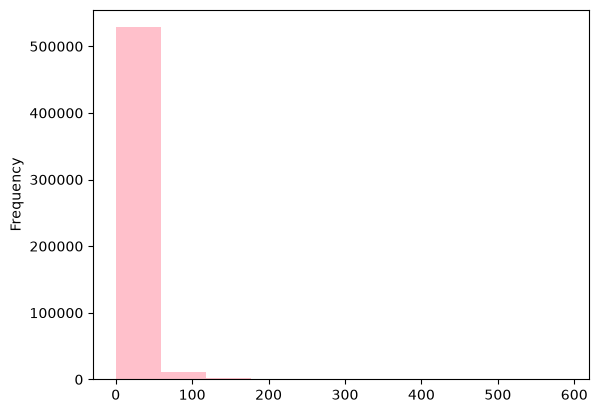

In [23]:
df["Rainfall"].plot(kind="hist", color="pink");

In [24]:
df.dtypes

StationIndex    int64
Station           str
Year            int64
Month           int64
Day             int64
Rainfall        int64
dtype: object

### Analysis: 
__Answering the objectives through data analysis__



In [25]:
# Creating new columns (Season column): 
def Seasons(Month): 
    if Month== 1 or Month== 2 or Month== 12 : 
        return "Winter"
    elif Month== 3 or Month== 4 or Month== 5:
        return "Pre-monsoon"
    elif Month== 6 or Month== 7 or Month== 8 or Month== 9:
        return "Monsoon" 
    else:
        return "Post-monsoon"


In [26]:
df["Seasons"] = df["Month"].apply(Seasons)

In [27]:
df

,StationIndex,Station,Year,Month,Day,Rainfall,Seasons
0,1,Dhaka,1970,1,1,0,Winter
1,1,Dhaka,1970,1,2,0,Winter
2,1,Dhaka,1970,1,3,0,Winter
3,1,Dhaka,1970,1,4,0,Winter
4,1,Dhaka,1970,1,5,0,Winter
...,...,...,...,...,...,...,...
542371,35,Sitakunda,2016,12,27,0,Winter
542372,35,Sitakunda,2016,12,28,0,Winter
542373,35,Sitakunda,2016,12,29,0,Winter
542374,35,Sitakunda,2016,12,30,0,Winter


![Coefficient of Variation Formula](https://toptipbio.com/wp-content/uploads/2017/04/Coefficient-of-variation-CV-formula.jpg)

In [28]:
# Creating new columns (Season column): 
def Seasons(Month): 
    if Month== 1 or Month== 2 or Month== 12 : 
        return "Winter"
    elif Month== 3 or Month== 4 or Month== 5:
        return "Pre-monsoon"
    elif Month== 6 or Month== 7 or Month== 8 or Month== 9:
        return "Monsoon" 
    else:
        return "Post-monsoon"


In [29]:
df.groupby(["Station","Year"]).Rainfall.sum() # Wait not all the years are there for each station!

Station      Year
Ambagan_ctg  1999    3277
             2000    3235
             2001    2288
             2002    2764
             2003    2696
                     ... 
sydpur       2012    1790
             2013    1722
             2014    1688
             2015    1885
             2016    1379
Name: Rainfall, Length: 1458, dtype: int64

In [30]:
df.groupby(["Station"]).Year.nunique()==47

Station
Ambagan_ctg    False
Barisal         True
Bhola           True
Bogra           True
Chandpur       False
Chittagong     False
Comilla        False
CoxsBazar       True
Dhaka          False
Dinajpur       False
Faridpur        True
Feni           False
Hatiya         False
Ishurdi         True
Jessore        False
Khepupara      False
Khulna         False
Kutubdia       False
M.court        False
Madaripur      False
Mongla         False
Mymensingh      True
Patuakhali     False
Rajshahi       False
Rangamati       True
Rangpur        False
Sandwip        False
Satkhira        True
Sitakunda      False
Srimangal      False
Sylhet         False
Tangail        False
Teknaf         False
chuadanga      False
sydpur         False
Name: Year, dtype: bool

In [31]:
#df.groupby(["Station"]).Year.nunique()

df_filtered=df.groupby(["Station","StationIndex"]).Year.nunique()==47
df_filtered.sum()

np.int64(9)

In [32]:
df_filtered

Station      StationIndex
Ambagan_ctg  34              False
Barisal      19               True
Bhola        20               True
Bogra        8                True
Chandpur     23              False
Chittagong   25              False
Comilla      26              False
CoxsBazar    27               True
Dhaka        1               False
Dinajpur     9               False
Faridpur     4                True
Feni         28              False
Hatiya       29              False
Ishurdi      10               True
Jessore      15              False
Khepupara    21              False
Khulna       16              False
Kutubdia     30              False
M.court      31              False
Madaripur    5               False
Mongla       17              False
Mymensingh   3                True
Patuakhali   22              False
Rajshahi     11              False
Rangamati    32               True
Rangpur      12              False
Sandwip      33              False
Satkhira     18              

In [33]:
df_filtered[df_filtered]


Station     StationIndex
Barisal     19              True
Bhola       20              True
Bogra       8               True
CoxsBazar   27              True
Faridpur    4               True
Ishurdi     10              True
Mymensingh  3               True
Rangamati   32              True
Satkhira    18              True
Name: Year, dtype: bool

In [34]:
 df["Station"].unique()

<ArrowStringArray>
[      'Dhaka',     'Tangail',  'Mymensingh',    'Faridpur',   'Madaripur',
   'Srimangal',      'Sylhet',       'Bogra',    'Dinajpur',     'Ishurdi',
    'Rajshahi',     'Rangpur',      'sydpur',   'chuadanga',     'Jessore',
      'Khulna',      'Mongla',    'Satkhira',     'Barisal',       'Bhola',
   'Khepupara',  'Patuakhali',    'Chandpur',      'Teknaf',  'Chittagong',
     'Comilla',   'CoxsBazar',        'Feni',      'Hatiya',    'Kutubdia',
     'M.court',   'Rangamati',     'Sandwip', 'Ambagan_ctg',   'Sitakunda']
Length: 35, dtype: str

In [35]:
stations_list = ["Barisal", "Bhola", "Bogra", "CoxsBazar", "Faridpur", "Ishurdi", "Mymensingh", "Rangamati", "Satkhira"]

In [36]:
the_filter= df["Station"].isin(stations_list)
df_= df[the_filter]

In [37]:
df_.reset_index(inplace= True ,drop=True)

In [38]:
df_

,StationIndex,Station,Year,Month,Day,Rainfall,Seasons
0,3,Mymensingh,1970,1,1,0,Winter
1,3,Mymensingh,1970,1,2,0,Winter
2,3,Mymensingh,1970,1,3,0,Winter
3,3,Mymensingh,1970,1,4,0,Winter
4,3,Mymensingh,1970,1,5,0,Winter
...,...,...,...,...,...,...,...
157351,32,Rangamati,2016,12,27,0,Winter
157352,32,Rangamati,2016,12,28,0,Winter
157353,32,Rangamati,2016,12,29,0,Winter
157354,32,Rangamati,2016,12,30,0,Winter


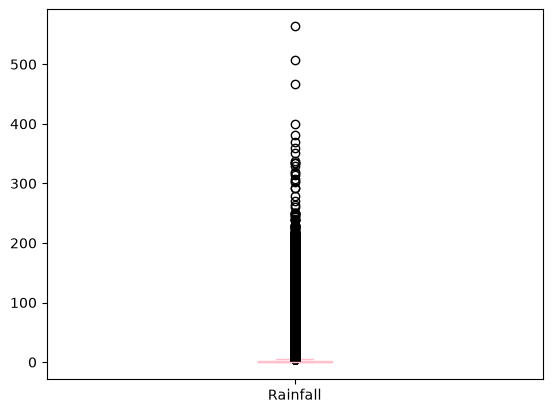

In [39]:
df_["Rainfall"].plot(kind="box", color="pink");

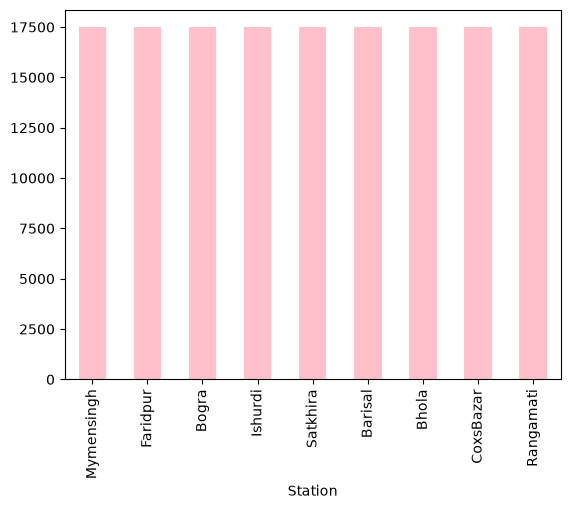

In [40]:
df_["Station"].value_counts().plot(kind="bar", color="pink");

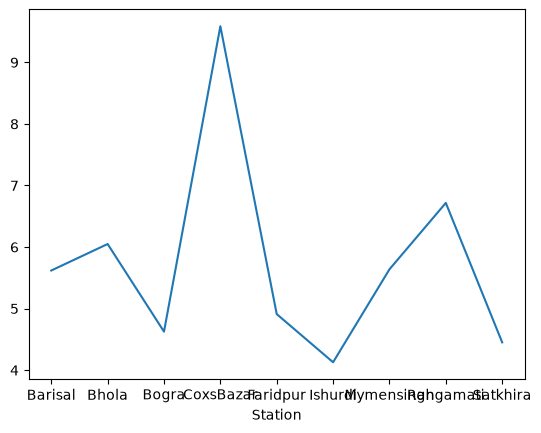

In [41]:
df_.sort_values(by="Year").groupby("Station").Rainfall.mean().plot();

In [42]:
df_.groupby("Station").Rainfall.mean()

Station
Barisal       5.618623
Bhola         6.049073
Bogra         4.625715
CoxsBazar     9.586937
Faridpur      4.910547
Ishurdi       4.128232
Mymensingh    5.638069
Rangamati     6.716884
Satkhira      4.450927
Name: Rainfall, dtype: float64

In [43]:
df_barisal= df_[df_["Station"] == "Barisal"]
df_Bhola= df_[df_["Station"] == "Bhola"]
df_Bogra= df_[df_["Station"] == "Bogra"]
df_CoxsBazar= df_[df_["Station"] == "CoxsBazar"]
df_Faridpur= df_[df_["Station"] == "Faridpur"]
df_Ishurdi= df_[df_["Station"] == "Ishurdi"]
df_Mymensingh= df_[df_["Station"] == "Mymensingh"]
df_Rangamati= df_[df_["Station"] == "Rangamati"]
df_Satkhira= df_[df_["Station"] == "Satkhira"]

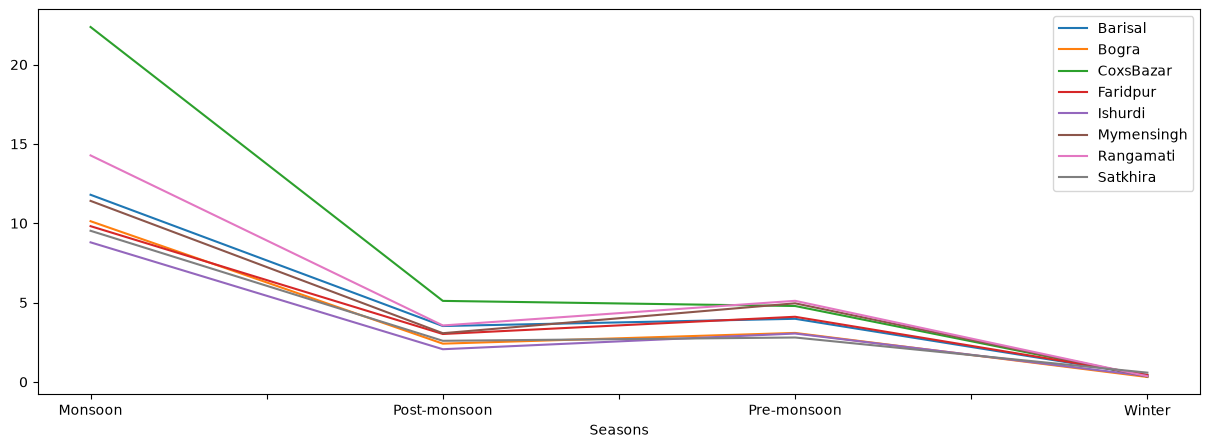

In [44]:
df_barisal.groupby("Seasons").Rainfall.mean().plot(figsize=(15, 5), label="Barisal");
df_Bogra.groupby("Seasons").Rainfall.mean().plot(figsize=(15, 5), label="Bogra");
df_CoxsBazar.groupby("Seasons").Rainfall.mean().plot(figsize=(15, 5), label="CoxsBazar");
df_Faridpur.groupby("Seasons").Rainfall.mean().plot(figsize=(15, 5), label="Faridpur");
df_Ishurdi.groupby("Seasons").Rainfall.mean().plot(figsize=(15, 5), label="Ishurdi");
df_Mymensingh.groupby("Seasons").Rainfall.mean().plot(figsize=(15, 5), label="Mymensingh");
df_Rangamati.groupby("Seasons").Rainfall.mean().plot(figsize=(15, 5), label="Rangamati");
df_Satkhira.groupby("Seasons").Rainfall.mean().plot(figsize=(15, 5), label="Satkhira");
plt.legend();




### Analysis: 
__Answering the objectives through data analysis__



In [45]:
# Creating new columns (decades column): 
def Decade(Year): 
    return (Year // 10) * 10
df_["Decades"] = df_["Year"].apply(Decade)

In [46]:
df_["Decades"]

0         1970
1         1970
2         1970
3         1970
4         1970
          ... 
157351    2010
157352    2010
157353    2010
157354    2010
157355    2010
Name: Decades, Length: 157356, dtype: int64

In [47]:
decade_names = {
    1970: "1st Decade",
    1980: "2nd Decade",
    1990: "3rd Decade",
    2000: "4th Decade",
    2010: "5th Decade"
}

In [48]:
df_["Decades"]=df_["Decades"].map(decade_names)

In [49]:
df_["Decades"]

0         1st Decade
1         1st Decade
2         1st Decade
3         1st Decade
4         1st Decade
             ...    
157351    5th Decade
157352    5th Decade
157353    5th Decade
157354    5th Decade
157355    5th Decade
Name: Decades, Length: 157356, dtype: str

In [50]:
df_barisal= df_[df_["Station"] == "Barisal"]
df_Bhola= df_[df_["Station"] == "Bhola"]
df_Bogra= df_[df_["Station"] == "Bogra"]
df_CoxsBazar= df_[df_["Station"] == "CoxsBazar"]
df_Faridpur= df_[df_["Station"] == "Faridpur"]
df_Ishurdi= df_[df_["Station"] == "Ishurdi"]
df_Mymensingh= df_[df_["Station"] == "Mymensingh"]
df_Rangamati= df_[df_["Station"] == "Rangamati"]
df_Satkhira= df_[df_["Station"] == "Satkhira"]

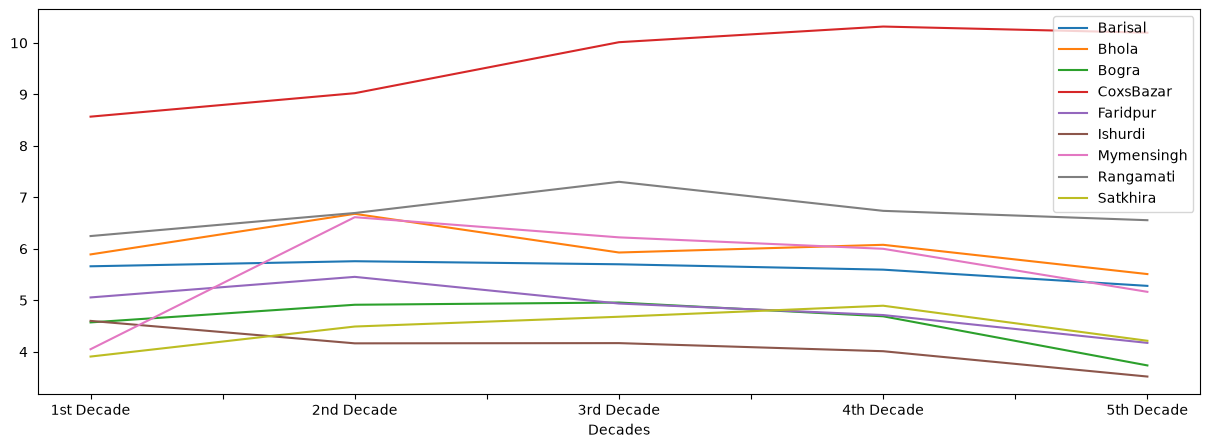

In [51]:
df_barisal.groupby("Decades").Rainfall.mean().plot(figsize=(15, 5), label="Barisal");
df_Bhola.groupby("Decades").Rainfall.mean().plot(figsize=(15, 5), label="Bhola");
df_Bogra.groupby("Decades").Rainfall.mean().plot(figsize=(15, 5), label="Bogra");
df_CoxsBazar.groupby("Decades").Rainfall.mean().plot(figsize=(15, 5), label="CoxsBazar");
df_Faridpur.groupby("Decades").Rainfall.mean().plot(figsize=(15, 5), label="Faridpur");
df_Ishurdi.groupby("Decades").Rainfall.mean().plot(figsize=(15, 5), label="Ishurdi");
df_Mymensingh.groupby("Decades").Rainfall.mean().plot(figsize=(15, 5), label="Mymensingh");
df_Rangamati.groupby("Decades").Rainfall.mean().plot(figsize=(15, 5), label="Rangamati");
df_Satkhira.groupby("Decades").Rainfall.mean().plot(figsize=(15, 5), label="Satkhira");

plt.legend();




### What are the top 3 regions with the highest average rainfall in the period of 1970-2016?


In [52]:
top3_stations= df_.groupby(["Station"])["Rainfall"].mean().sort_values(ascending=True)

In [53]:
top3_stations.head(3)

Station
Ishurdi     4.128232
Satkhira    4.450927
Bogra       4.625715
Name: Rainfall, dtype: float64

In [54]:
top3_stations

Station
Ishurdi       4.128232
Satkhira      4.450927
Bogra         4.625715
Faridpur      4.910547
Barisal       5.618623
Mymensingh    5.638069
Bhola         6.049073
Rangamati     6.716884
CoxsBazar     9.586937
Name: Rainfall, dtype: float64

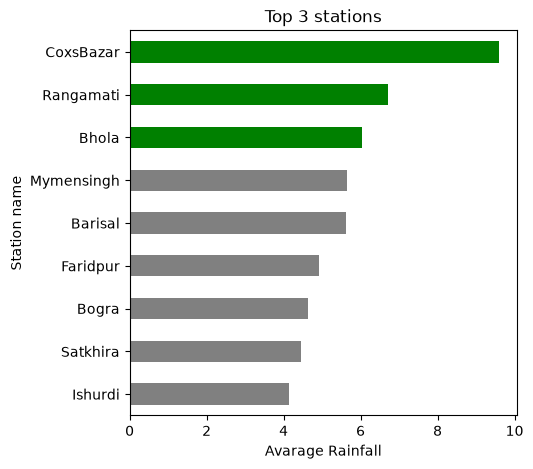

In [55]:
top3_stations.plot(kind="barh",color=["gray","gray","gray","gray","gray","gray","green","green","green"],title="Top 3 stations",ylabel="Station name",xlabel="Avarage Rainfall",figsize=(5,5));

### What are the best months regarding the highest average rainfall with the lowest coefficient of variation for planting, from 1970 to 2016?


In [56]:
monthly_totals = df.groupby(["Station", "Year", "Month"])["Rainfall"].sum()

In [57]:
monthly_totals

Station      Year  Month
Ambagan_ctg  1999  1          0
                   2          0
                   3          1
                   4          0
                   5        403
                           ... 
sydpur       2016  8         90
                   9        335
                   10       102
                   11         0
                   12         6
Name: Rainfall, Length: 17496, dtype: int64

In [58]:
monthly_totals.groupby(level="Month").mean().sort_values(ascending=False) # the mean of all the months of the years in Bangladesh

Month
7     523.070645
6     457.611111
8     410.847737
9     321.294239
5     271.062414
10    180.043896
4     112.017147
3      42.958848
11     38.061728
2      20.424554
12      8.339506
1       7.259259
Name: Rainfall, dtype: float64

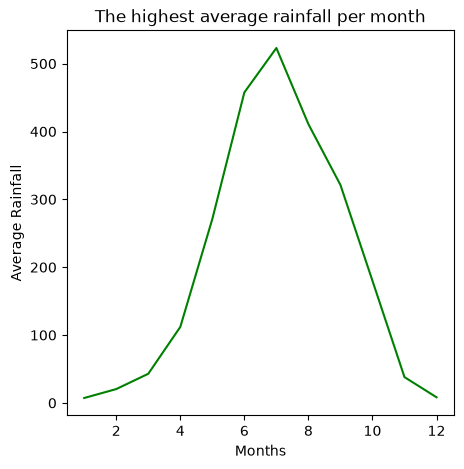

In [59]:
monthly_totals.groupby(level="Month").mean().plot(kind="line",color="green", figsize=(5,5), title="The highest average rainfall per month", xlabel="Months", ylabel="Average Rainfall");

In [60]:
monthly_totals.groupby(level="Month").std()

Month
1      13.800669
2      28.615840
3      60.112703
4     112.242429
5     176.298811
6     280.057324
7     309.262245
8     240.171333
9     176.686024
10    140.049220
11     68.952384
12     20.094371
Name: Rainfall, dtype: float64

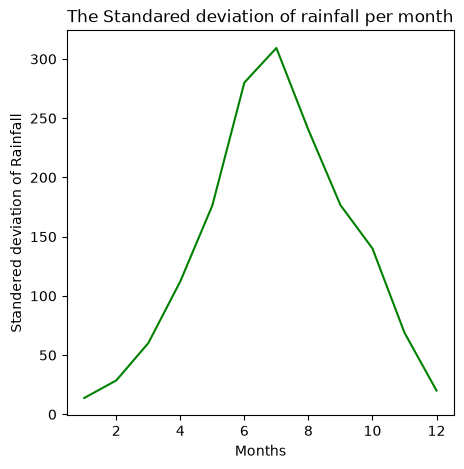

In [61]:
monthly_totals.groupby(level="Month").std().plot(kind="line",color="green", figsize=(5,5), title="The Standared deviation of rainfall per month", xlabel="Months", ylabel="Standered deviation of Rainfall");

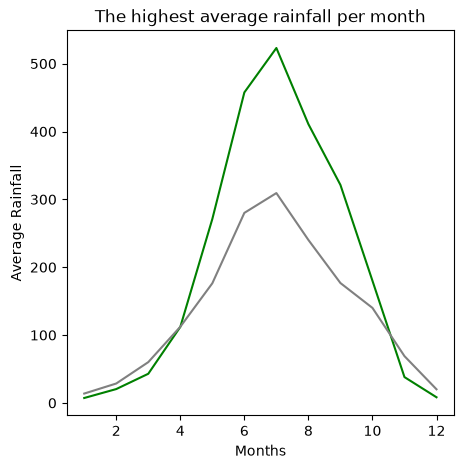

In [62]:
monthly_totals.groupby(level="Month").mean().plot(kind="line",color="green", figsize=(5,5), title="The highest average rainfall per month", xlabel="Months", ylabel="Average Rainfall");
monthly_totals.groupby(level="Month").std().plot(kind="line",color="gray", figsize=(5,5), title="The highest average rainfall per month", xlabel="Months", ylabel="Average Rainfall");

In [63]:
Cv=(monthly_totals.groupby(level="Month").std()/monthly_totals.groupby(level="Month").mean())*100

In [64]:
Cv.sort_values()
# the best 9, 8,7,6 

Month
9      54.991968
8      58.457504
7      59.124374
6      61.199852
5      65.039932
10     77.786153
4     100.201114
3     139.930902
2     140.105090
11    181.159362
1     190.111262
12    240.953973
Name: Rainfall, dtype: float64

In [65]:
monthly_totals.groupby(level="Month").mean().sort_values(ascending=False) # the mean of all the months of the years in Bangladesh
# the most 7,6,8,9

Month
7     523.070645
6     457.611111
8     410.847737
9     321.294239
5     271.062414
10    180.043896
4     112.017147
3      42.958848
11     38.061728
2      20.424554
12      8.339506
1       7.259259
Name: Rainfall, dtype: float64

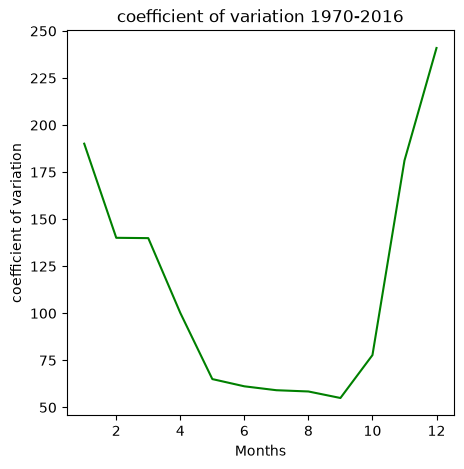

In [66]:
Cv.plot(kind="line",color="green", figsize=(5,5), title="coefficient of variation 1970-2016", xlabel="Months", ylabel="coefficient of variation");
# the less teh best , more stable 

In [67]:
Decades_totals = df_.groupby(["Station","Decades", "Year"])["Rainfall"].sum()

In [68]:
Decades_totals

Station   Decades     Year
Barisal   1st Decade  1970    2413
                      1971    2025
                      1972    1396
                      1973    2877
                      1974    2346
                              ... 
Satkhira  5th Decade  2012    1458
                      2013    1662
                      2014    1298
                      2015    1792
                      2016    1345
Name: Rainfall, Length: 423, dtype: int64

### How does the Coefficient of Variation of rainfall in different weather stations in Bangladesh change across decades from 1970 to 2016? :

In [69]:
Cv_=(Decades_totals.groupby(level=["Station","Decades"]).std()/Decades_totals.groupby(level=["Station","Decades"]).mean())*100

In [76]:
Cv_pivot = Cv_.unstack("Station")

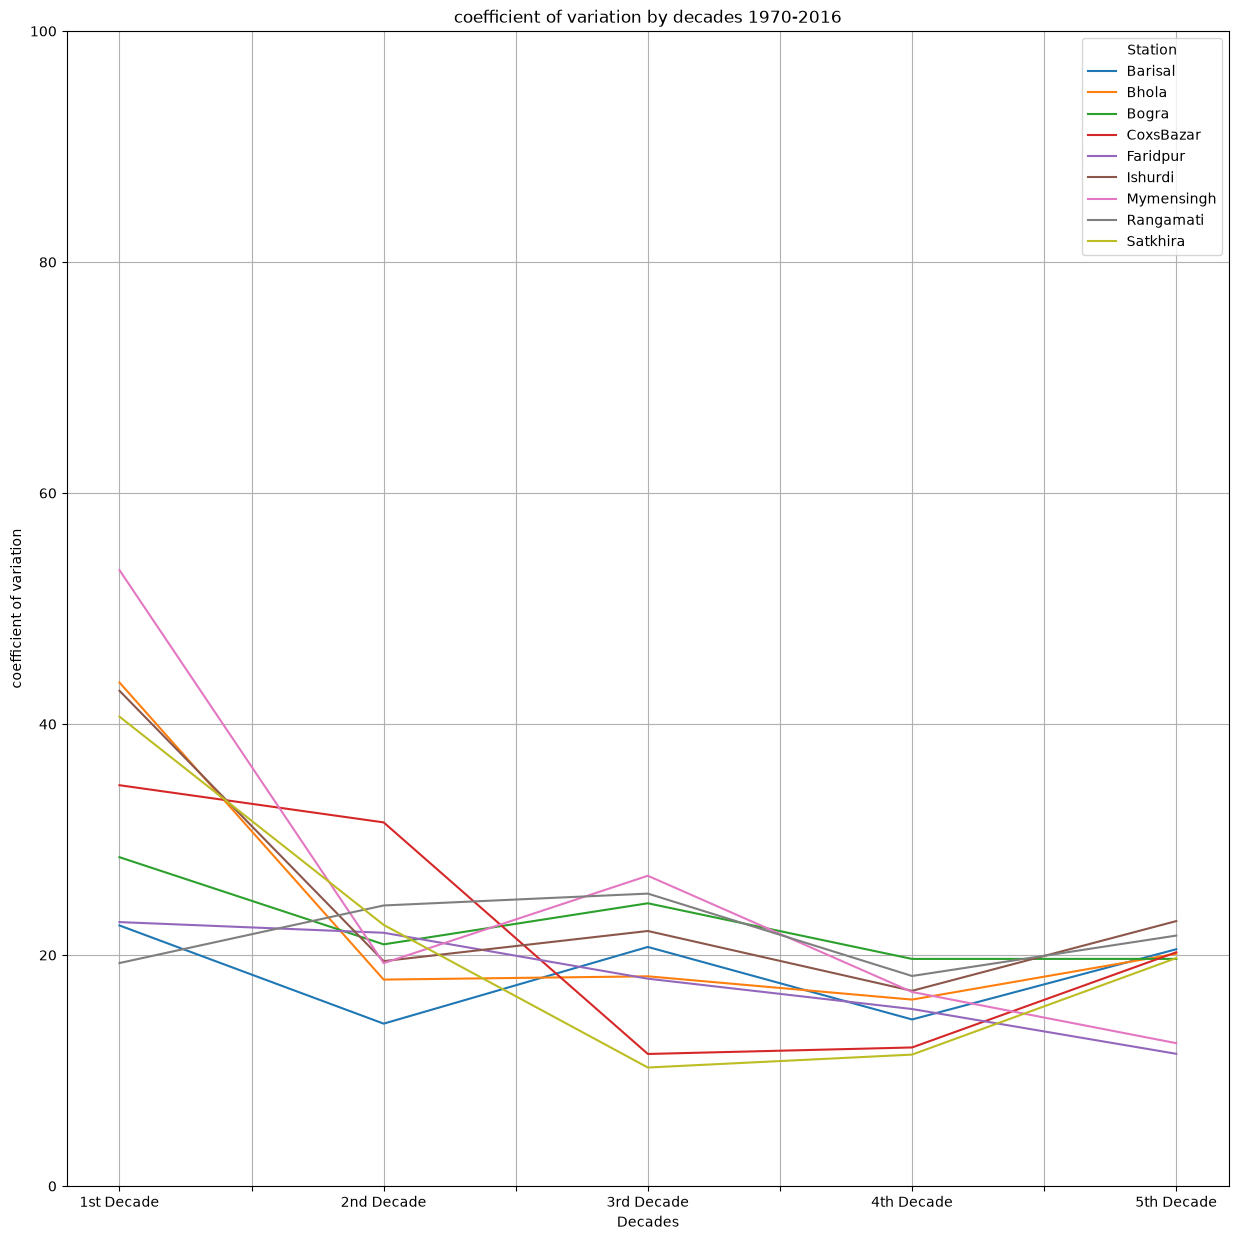

In [78]:
Cv_pivot.plot(kind="line", figsize=(15,15), title="coefficient of variation by decades 1970-2016", ylabel="coefficient of variation",ylim=(0,100), grid=True);
# the less teh best , more stable 

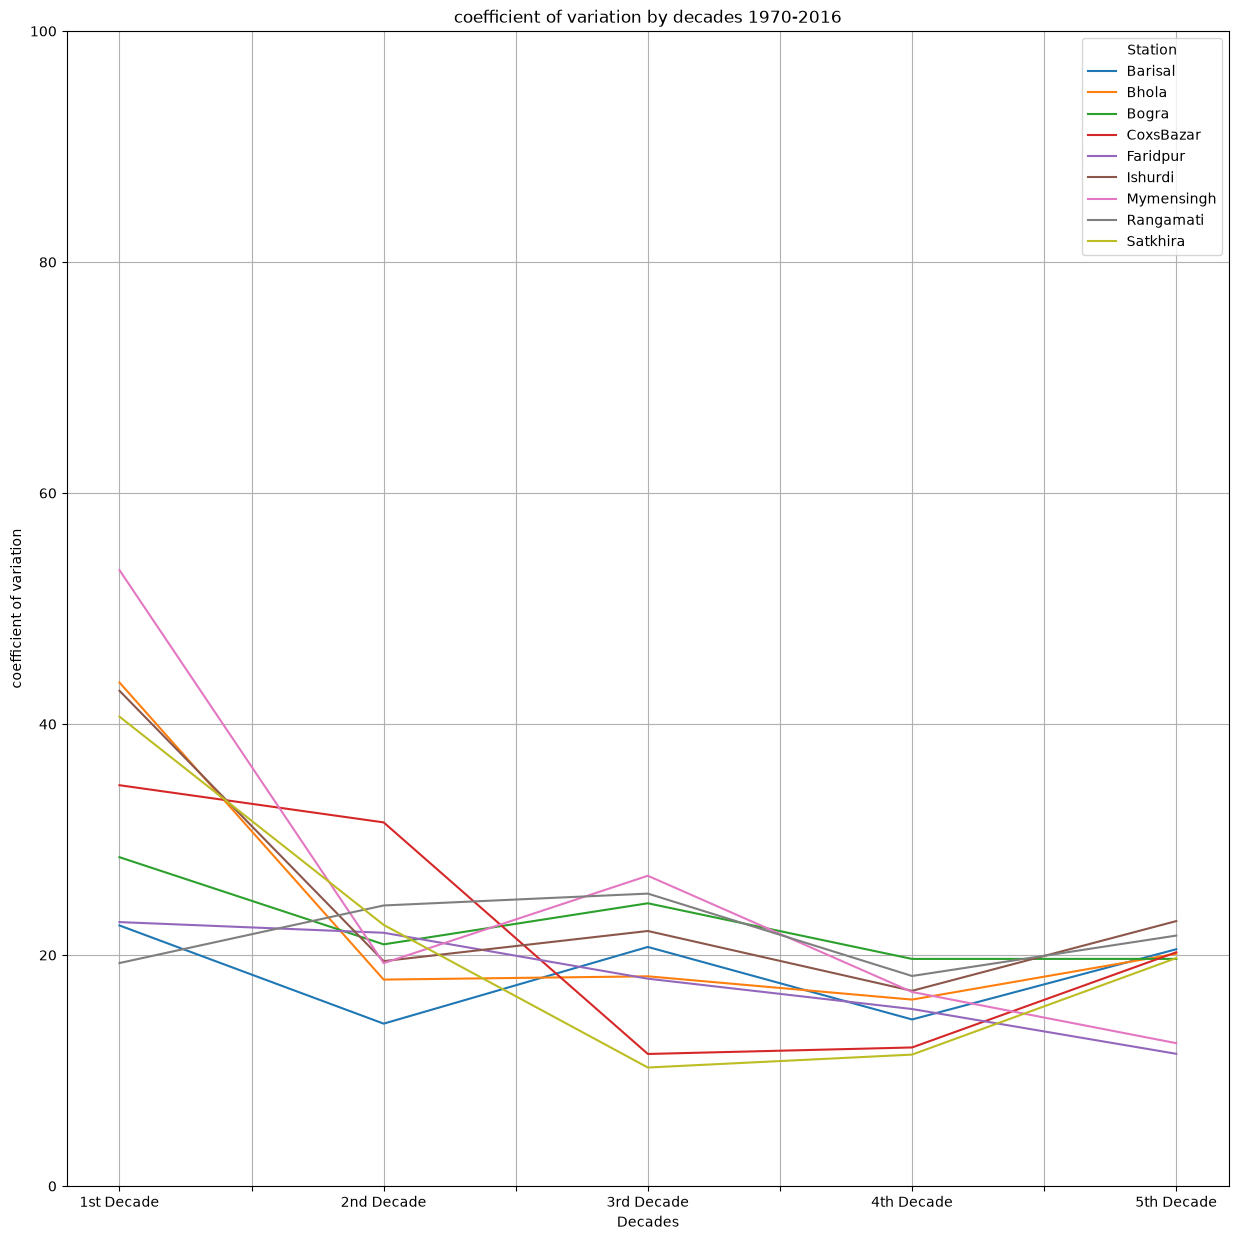

In [78]:
Cv_pivot.plot(kind="line", figsize=(15,15), title="coefficient of variation by decades 1970-2016", ylabel="coefficient of variation",ylim=(0,100), grid=True);
# the less teh best , more stable 

In [79]:
'''
Rainfall variability differs from station to station, with no single consistent pattern across the country. Some stations became more stable over time, while others—especially coastal ones—showed increasing variability in recent decades.
'''

'\nRainfall variability differs from station to station, with no single consistent pattern across the country. Some stations became more stable over time, while others—especially coastal ones—showed increasing variability in recent decades.\n'

### - Which season recorded the highest number of months exceeding the Standard Deviation-based rainfall threshold between 1970 and 2016?

In [80]:
monthly_totals.groupby(level="Month").mean().sort_values(ascending=False)
overall_mean = monthly_totals.mean()
overall_std = monthly_totals.std()

In [81]:
overall_mean

np.float64(199.41592363968908)

In [82]:
overall_std

np.float64(247.6505817681638)

![](https://rodgers-associates.com/wp-content/uploads/Standard-Diviation.gif)

In [104]:
threshold=overall_mean+(2*overall_std)

In [105]:
threshold

np.float64(694.7170871760167)

In [113]:
monthly_totals_df = monthly_totals.reset_index()

In [114]:
monthly_totals_df

,Station,Year,Month,Rainfall
0,Ambagan_ctg,1999,1,0
1,Ambagan_ctg,1999,2,0
2,Ambagan_ctg,1999,3,1
3,Ambagan_ctg,1999,4,0
4,Ambagan_ctg,1999,5,403
...,...,...,...,...
17491,sydpur,2016,8,90
17492,sydpur,2016,9,335
17493,sydpur,2016,10,102
17494,sydpur,2016,11,0


In [115]:
monthly_totals_df["Seasons"] = monthly_totals_df["Month"].apply(Seasons)

In [116]:
monthly_totals_df

,Station,Year,Month,Rainfall,Seasons
0,Ambagan_ctg,1999,1,0,Winter
1,Ambagan_ctg,1999,2,0,Winter
2,Ambagan_ctg,1999,3,1,Pre-monsoon
3,Ambagan_ctg,1999,4,0,Pre-monsoon
4,Ambagan_ctg,1999,5,403,Pre-monsoon
...,...,...,...,...,...
17491,sydpur,2016,8,90,Monsoon
17492,sydpur,2016,9,335,Monsoon
17493,sydpur,2016,10,102,Post-monsoon
17494,sydpur,2016,11,0,Post-monsoon


In [117]:
monthly_totals_df["Exceeded"] = monthly_totals_df["Rainfall"] > threshold

In [118]:
monthly_totals_df

,Station,Year,Month,Rainfall,Seasons,Exceeded
0,Ambagan_ctg,1999,1,0,Winter,False
1,Ambagan_ctg,1999,2,0,Winter,False
2,Ambagan_ctg,1999,3,1,Pre-monsoon,False
3,Ambagan_ctg,1999,4,0,Pre-monsoon,False
4,Ambagan_ctg,1999,5,403,Pre-monsoon,False
...,...,...,...,...,...,...
17491,sydpur,2016,8,90,Monsoon,False
17492,sydpur,2016,9,335,Monsoon,False
17493,sydpur,2016,10,102,Post-monsoon,False
17494,sydpur,2016,11,0,Post-monsoon,False


In [119]:
result = monthly_totals_df.groupby("Seasons")["Exceeded"].sum()


In [120]:
result

Seasons
Monsoon         826
Post-monsoon      6
Pre-monsoon      56
Winter            0
Name: Exceeded, dtype: int64

In [123]:
perc = (monthly_totals_df.groupby("Seasons")["Exceeded"].sum() / monthly_totals_df["Exceeded"].sum())*100
perc

Seasons
Monsoon         93.018018
Post-monsoon     0.675676
Pre-monsoon      6.306306
Winter           0.000000
Name: Exceeded, dtype: float64

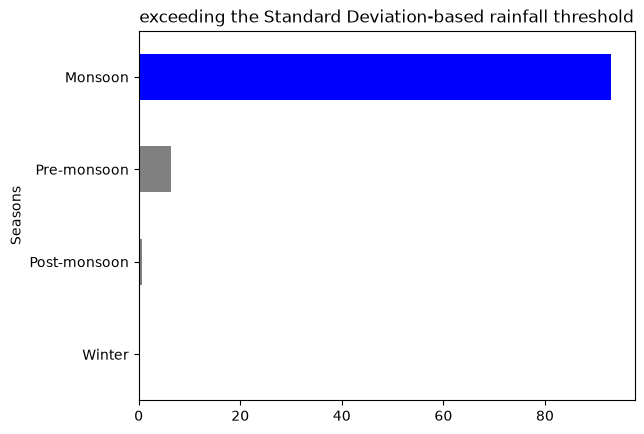

In [156]:
perc.sort_values(ascending=True).plot(
    kind="barh", 
    color=["gray", "gray","gray","blue"]
    , title="exceeding the Standard Deviation-based rainfall threshold"
);

In [ ]:
'''
The Monsoon season (June–September) accounts for 93% of all months with extreme rainfall between 1970 and 2016. 
This makes it by far the highest-risk season for flooding, while Winter recorded no extreme rainfall events at all.

'''

### What is the correlation between the average rainfall and the Coefficient of Variation across weather stations, from 1970 to 2016?

In [162]:
yearly_totals = df_.groupby(["Station", "Year"])["Rainfall"].sum()
yearly_totals 

Station   Year
Barisal   1970    2413
          1971    2025
          1972    1396
          1973    2877
          1974    2346
                  ... 
Satkhira  2012    1458
          2013    1662
          2014    1298
          2015    1792
          2016    1345
Name: Rainfall, Length: 423, dtype: int64

In [163]:
station_mean = yearly_totals.groupby(level="Station").mean()
station_std = yearly_totals.groupby(level="Station").std()

In [164]:
station_cv = (station_std / station_mean) * 100

In [165]:
station_cv

Station
Barisal       18.005663
Bhola         24.984007
Bogra         23.944099
CoxsBazar     23.156178
Faridpur      20.232700
Ishurdi       28.027575
Mymensingh    30.321693
Rangamati     21.852408
Satkhira      22.672182
Name: Rainfall, dtype: float64

In [166]:
combined = pd.DataFrame({"Mean": station_mean, "CV": station_cv})

In [167]:
combined["Mean"].corr(combined["CV"])

np.float64(-0.13048135060205493)

In [ ]:
'''
The correlation between average rainfall and Coefficient of Variation across stations is very weak (-0.13)
, meaning rainfall amount does not predict rainfall stability. 
Each station's variability should be assessed individually.

'''

---

In [168]:
####first step 

df.groupby(["StationIndex"]).Year.nunique()==47
#3 , 4, 8, 10, 18 , 19 , 20 , 27, 32

StationIndex
1     False
2     False
3      True
4      True
5     False
6     False
7     False
8      True
9     False
10     True
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18     True
19     True
20     True
21    False
22    False
23    False
24    False
25    False
26    False
27     True
28    False
29    False
30    False
31    False
32     True
33    False
34    False
35    False
Name: Year, dtype: bool

In [169]:
df.groupby(["Station","StationIndex"]).Year.nunique()==47


Station      StationIndex
Ambagan_ctg  34              False
Barisal      19               True
Bhola        20               True
Bogra        8                True
Chandpur     23              False
Chittagong   25              False
Comilla      26              False
CoxsBazar    27               True
Dhaka        1               False
Dinajpur     9               False
Faridpur     4                True
Feni         28              False
Hatiya       29              False
Ishurdi      10               True
Jessore      15              False
Khepupara    21              False
Khulna       16              False
Kutubdia     30              False
M.court      31              False
Madaripur    5               False
Mongla       17              False
Mymensingh   3                True
Patuakhali   22              False
Rajshahi     11              False
Rangamati    32               True
Rangpur      12              False
Sandwip      33              False
Satkhira     18              

---

## Summary

- Highest rainfall regions: CoxsBazar, Rangamati, and Bhola recorded the highest average rainfall among the nine stations (1970-2016), while Ishurdi, Satkhira, and Bogra recorded the lowest.
- Best planting months: July had the highest average rainfall (523mm) combined with a relatively low Coefficient of Variation (~59%), making the Monsoon months (June-September) the most reliable period for planting.
- Variability across decades: Rainfall variability does not follow one consistent trend across Bangladesh. Some stations became more stable over time, while others—especially coastal ones—showed increasing variability in recent decades.
- Flood risk by season: The Monsoon season accounts for 93% of all months with extreme rainfall recorded between 1970 and 2016, making it by far the highest-risk season for flooding.
- Rainfall amount vs. stability: The correlation between average rainfall and Coefficient of Variation across stations is very weak (-0.13), indicating that rainfall amount does not reliably predict how stable a station's rainfall pattern is.

## Recommendations/Conclusion

- Prioritize Monsoon-season flood monitoring: Since the Monsoon season (June-September) accounts for 93% of all extreme rainfall months, disaster management authorities should concentrate flood monitoring and early-warning resources during this period, especially at coastal stations.
- Use July-September as the primary planting window: Farmers can rely on the Monsoon months, particularly July, as the most favorable period for planting due to consistently high average rainfall combined with relatively low variability.
- Monitor coastal stations more closely: Since coastal stations (e.g., CoxsBazar) showed increasing rainfall variability in recent decades, these regions should receive additional monitoring and adaptive water management planning.
- Avoid generalizing station behavior by rainfall amount alone: Because rainfall amount and variability are weakly correlated, each station should be assessed individually for its own variability pattern rather than assuming similar stations behave the same way.
  
**Conclusion: Rainfall in Bangladesh does not follow a single uniform pattern across stations or decades. A localized, season-aware approach to agricultural planning and flood risk management is more effective than a one-size-fits-all national strategy.**

In [170]:
df_.shape

(157356, 8)

In [171]:
df.groupby("Station")["Year"].agg(["min", "max", "count"])


,min,max,count
Station,,,
Ambagan_ctg,1999,2016,6696
Barisal,1970,2016,17484
Bhola,1970,2016,17484
Bogra,1970,2016,17484
Chandpur,1970,2016,15996
Chittagong,1970,2016,15996
Comilla,1970,2016,17112
CoxsBazar,1970,2016,17484
Dhaka,1970,2016,17112


chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://mdass.bmd.gov.bd/file/2021/02/16/pdf/109888.pdf

In [174]:
df["Station"].unique()

<ArrowStringArray>
[      'Dhaka',     'Tangail',  'Mymensingh',    'Faridpur',   'Madaripur',
   'Srimangal',      'Sylhet',       'Bogra',    'Dinajpur',     'Ishurdi',
    'Rajshahi',     'Rangpur',      'sydpur',   'chuadanga',     'Jessore',
      'Khulna',      'Mongla',    'Satkhira',     'Barisal',       'Bhola',
   'Khepupara',  'Patuakhali',    'Chandpur',      'Teknaf',  'Chittagong',
     'Comilla',   'CoxsBazar',        'Feni',      'Hatiya',    'Kutubdia',
     'M.court',   'Rangamati',     'Sandwip', 'Ambagan_ctg',   'Sitakunda']
Length: 35, dtype: str

In [176]:
df_["Station"].unique()

<ArrowStringArray>
['Mymensingh',   'Faridpur',      'Bogra',    'Ishurdi',   'Satkhira',
    'Barisal',      'Bhola',  'CoxsBazar',  'Rangamati']
Length: 9, dtype: str

In [177]:
df.groupby("Station").Year.nunique()

Station
Ambagan_ctg    18
Barisal        47
Bhola          47
Bogra          47
Chandpur       43
Chittagong     43
Comilla        46
CoxsBazar      47
Dhaka          46
Dinajpur       39
Faridpur       47
Feni           44
Hatiya         41
Ishurdi        47
Jessore        46
Khepupara      43
Khulna         46
Kutubdia       35
M.court        45
Madaripur      39
Mongla         26
Mymensingh     47
Patuakhali     42
Rajshahi       46
Rangamati      47
Rangpur        46
Sandwip        45
Satkhira       47
Sitakunda      40
Srimangal      46
Sylhet         46
Tangail        30
Teknaf         40
chuadanga      28
sydpur         26
Name: Year, dtype: int64

In [179]:
station_years=df.groupby("Station").Year.nunique().sort_values(ascending=False)

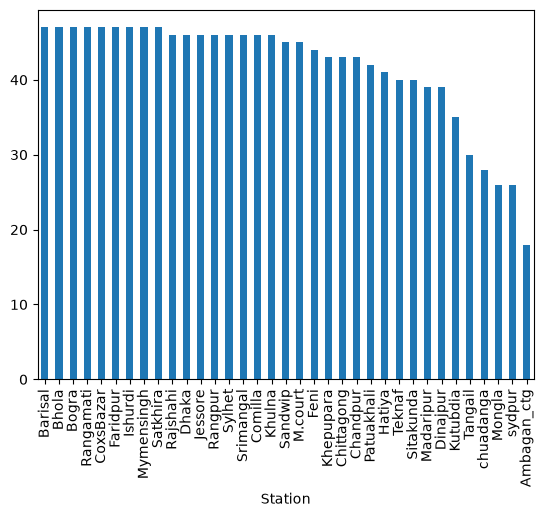

In [181]:
station_years.plot(kind="bar");

In [182]:
station_years = df.groupby("Station")["Year"].apply(set)

common_years = sorted(set.intersection(*station_years))

print(common_years)

[1999, 2000, 2001, 2002, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]


In [187]:
stations = df["Station"].nunique()

years = df.groupby("Year")["Station"].nunique()

common_years = years[years == stations]

print(common_years)

Year
1999    35
2000    35
2001    35
2002    35
2008    35
2009    35
2010    35
2011    35
2012    35
2013    35
2014    35
2015    35
2016    35
Name: Station, dtype: int64
